In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [37]:
data = pd.read_csv("Weather-2020-2025.csv")


In [38]:
data["time"] = pd.to_datetime(data["time"])
data.head(3)
data.dropna()
data["date"] = data["time"].dt.date

In [39]:
data.head(3)

,location_id,time,temperature_2m,relative_humidity_2m (%),wind_speed_10m (km/h),precipitation (mm),is_day,wind_speed_100m (km/h),wind_gusts_10m (km/h),wind_direction_100m,wind_direction_10m,cloud_cover (%),vapour_pressure_deficit (kPa),date
0,0,2024-01-01 00:00:00,7.7,77,30.6,0.0,0,48.2,51.8,246,243,90,0.25,2024-01-01
1,0,2024-01-01 01:00:00,7.6,77,29.5,0.0,0,47.4,50.8,249,246,60,0.24,2024-01-01
2,0,2024-01-01 02:00:00,7.3,78,29.0,0.0,0,47.0,49.3,248,245,22,0.22,2024-01-01


In [40]:
data["location_id"] = data["location_id"].replace(0, "London")
data["location_id"] = data["location_id"].replace(1, "Dublin")
data["location_id"] = data["location_id"].replace(2, "Lisbon")

In [41]:
average_temp = data.groupby("location_id")["temperature_2m"].mean()
lowest_city = average_temp.idxmin()
lowest_temp = average_temp.min()

print(lowest_city)
print(lowest_temp)

Dublin
11.22532489740082


In [42]:
total_rainfall = data.groupby("location_id")["precipitation (mm)"].sum()
lowest_rainfall = total_rainfall.idxmin()
lowest_raifallnum = total_rainfall.min()


print(lowest_rainfall)
print(lowest_raifallnum)

London
1507.0


In [43]:
average_windspeed = data.groupby("location_id")["wind_speed_100m (km/h)"].mean()
highest_windspeed_city = average_windspeed.idxmax()
highest_windspeed = average_windspeed.max()

print(highest_windspeed_city)
print(highest_windspeed)

Dublin
25.924304605563155


In [44]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52632 entries, 0 to 52631
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   location_id                    52632 non-null  object        
 1   time                           52632 non-null  datetime64[ns]
 2   temperature_2m                 52632 non-null  float64       
 3   relative_humidity_2m (%)       52632 non-null  int64         
 4   wind_speed_10m (km/h)          52632 non-null  float64       
 5   precipitation (mm)             52632 non-null  float64       
 6   is_day                         52632 non-null  int64         
 7   wind_speed_100m (km/h)         52632 non-null  float64       
 8   wind_gusts_10m (km/h)          52632 non-null  float64       
 9   wind_direction_100m            52632 non-null  int64         
 10  wind_direction_10m             52632 non-null  int64         
 11  cloud_cover (%)

In [45]:
def directional_consistency(x):
    rad = np.deg2rad(x.dropna())
    return np.sqrt(
        np.mean(np.cos(rad))**2 +
        np.mean(np.sin(rad))**2
    )

consistency = (
    data.groupby("location_id")["wind_direction_100m"]
        .apply(directional_consistency)
)

best_location = consistency.idxmax()
best_score = consistency.max()

print(f"Most consistent wind direction: {best_location}")
print(f"Consistency score: {best_score:.4f}")


Most consistent wind direction: Lisbon
Consistency score: 0.3905


Month
1      5.550874
2      7.636404
3      8.313441
4      9.926111
5     13.015927
6     14.591181
7     16.110618
8     16.628696
9     13.469653
10    11.868145
11     9.147986
12     8.227487
Name: temperature_2m, dtype: float64


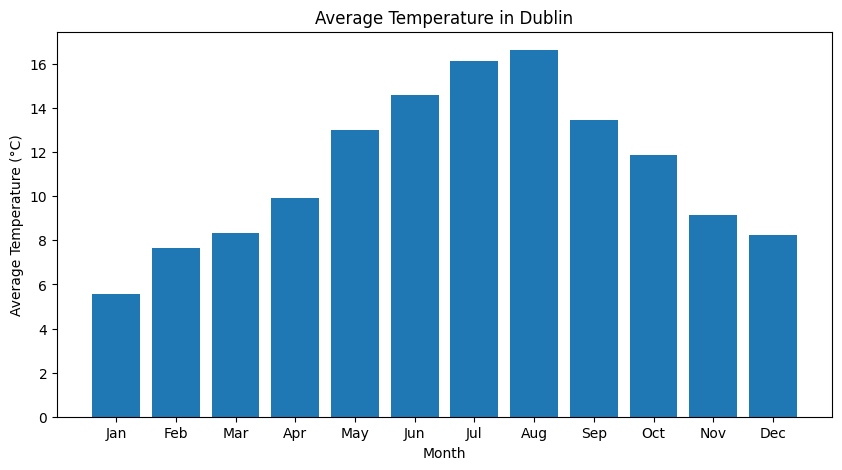

In [46]:
# Bar chart for the average temperature each month in Dublin
dublin = data[data['location_id'] == "Dublin"].copy()

dublin["Month"] = dublin["time"].dt.month


mean_temp_month = dublin.groupby("Month")["temperature_2m"].mean()

print(mean_temp_month)

month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

plt.figure(figsize=(10,5))
plt.bar(month_labels, mean_temp_month.values)

plt.xlabel("Month")
plt.ylabel("Average Temperature (°C)")
plt.title("Average Temperature in Dublin")

plt.show()

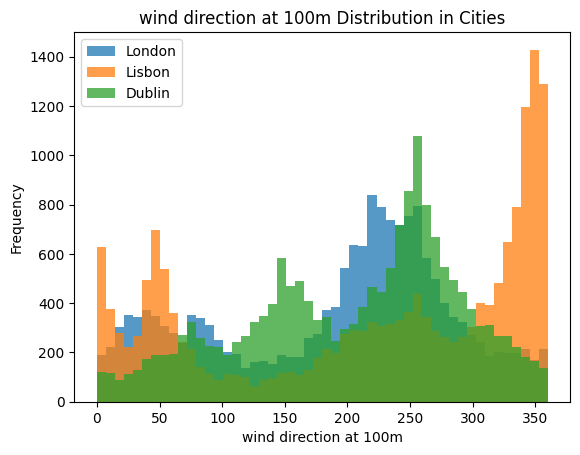

In [47]:
#histogram for wind direction of each city overlapping
london = data[data["location_id"] == "London"].copy()

dublin = data[data["location_id"] == "Dublin"].copy()

lisbon = data[data["location_id"] == "Lisbon"].copy()
bins = 50
plt.hist(london["wind_direction_100m"], bins=bins, label="London", alpha = 0.75)
plt.hist(lisbon["wind_direction_100m"], bins=bins, label="Lisbon", alpha = 0.75)
plt.hist(dublin["wind_direction_100m"], bins=bins, label="Dublin", alpha = 0.75)

plt.xlabel("wind direction at 100m")
plt.ylabel("Frequency")
plt.title("wind direction at 100m Distribution in Cities")
plt.legend()


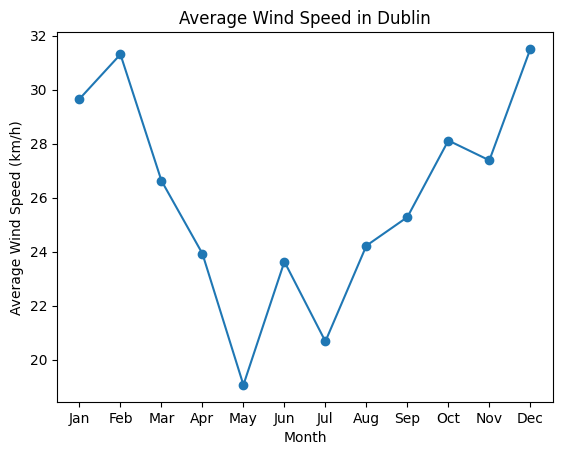

In [48]:

fig = plt.figure()
dublin = data[data["location_id"] == "Dublin"].copy()

dublin["Month"] = dublin["time"].dt.month

mean_wind_month = dublin.groupby("Month")["wind_speed_100m (km/h)"].mean()


month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

plt.plot(month_labels, mean_wind_month, marker="o")

plt.xlabel("Month")
plt.ylabel("Average Wind Speed (km/h)")
plt.title("Average Wind Speed in Dublin")

plt.show()
fig.savefig("average_wind_speed_dublin_line.png")


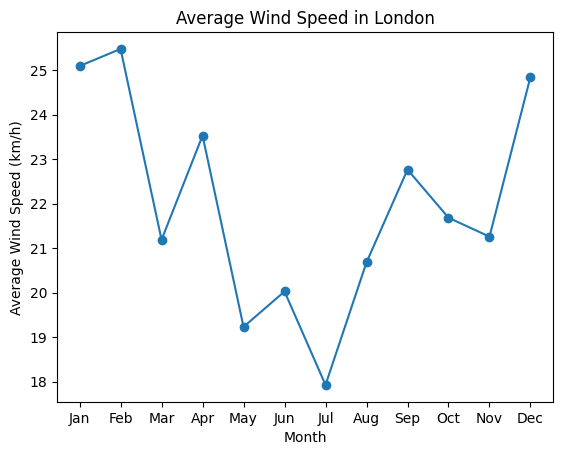

In [49]:
fig = plt.figure()
london = data[data["location_id"] == "London"].copy()

london["Month"] = london["time"].dt.month

mean_wind_month = london.groupby("Month")["wind_speed_100m (km/h)"].mean()


month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

plt.plot(month_labels, mean_wind_month, marker="o")

plt.xlabel("Month")
plt.ylabel("Average Wind Speed (km/h)")
plt.title("Average Wind Speed in London")

plt.show()
fig.savefig("average_wind_speed_london_line.png")

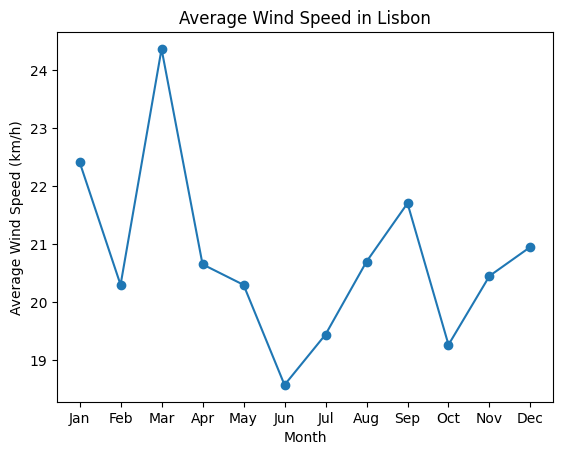

In [50]:
fig = plt.figure()
lisbon = data[data["location_id"] == "Lisbon"].copy()

lisbon["Month"] = lisbon["time"].dt.month

mean_wind_month = lisbon.groupby("Month")["wind_speed_100m (km/h)"].mean()


month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

plt.plot(month_labels, mean_wind_month, marker="o")

plt.xlabel("Month")
plt.ylabel("Average Wind Speed (km/h)")
plt.title("Average Wind Speed in Lisbon")

plt.show()
fig.savefig("average_wind_speed_lisbon_line.png")

In [51]:
data.groupby("location_id")["wind_speed_100m (km/h)"].agg(
    ["mean", "max", "min", "std"]
)

,mean,max,min,std
location_id,,,,
Dublin,25.924305,93.6,0.0,12.318492
Lisbon,20.770235,76.4,0.2,9.950264
London,21.951408,79.5,0.0,10.267639
